In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ROOT

Welcome to JupyROOT 6.30/04


In [2]:
# Asegurarse que AUGEROFFLINEROOT está definido
AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError("AUGEROFFLINEROOT no definido. Hacé 'source this-auger-offline.sh' primero.")

# -----------------------------
# Cargar librerías Offline
# -----------------------------
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    ROOT.gSystem.Load(os.path.join(AugerOfflineRoot, "lib", lib))


In [3]:
# -----------------------------
# Funciones auxiliares para el MD
# -----------------------------
def getCounterList(sevent, mevent):
    """
    Obtener la lista de counters UMD asociados a las estaciones SD de un evento.

    Parameters
    ----------
    sevent : SDEvent
        Evento reconstruido de superficie.
    mevent : MDEvent
        Evento de muones detectados.

    Returns
    -------
    list of Counter
        Lista de counters (UMD) presentes en el evento.

    Notes
    -----
    Cada Counter representa una estación UMD:
      - Métodos importantes:
        - HasModule(modId) -> bool
        - GetModule(modId) -> Module
        - IsRejected() / IsSaturated() -> bool
      - Contiene módulos (scintillators) donde se detectan muones.
    """
    cList = []
    stationVector = sevent.GetStationVector()
    for station in stationVector:
        stationId = station.GetId()
        counterId = int("10" + str(stationId))
        if mevent.HasCounter(counterId):
            cList.append(mevent.GetCounter(counterId))
    return cList

def getModuleList(counter, sim=True):
    """
    Obtener la lista de módulos (scintillators) de un counter UMD.

    Parameters
    ----------
    counter : Counter
        Counter UMD del que se extraen los módulos.
    sim : bool, default=True
        Indica si es simulación (módulos 0-5) o dato real (100-115).

    Returns
    -------
    list of Module
        Lista de módulos válidos.

    Notes
    -----
    Cada Module contiene información de detección de muones:
      - Métodos importantes:
        - IsRejected() / IsSaturated() -> bool
        - Se puede extraer el número de muones detectados por módulo.
    """
    possibleModules = range(0,6) if sim else range(100,116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules


In [4]:
# -----------------------------
# Función principal de lectura
# -----------------------------
def readADST_surface(fname):
    """
    Leer archivos ADST y extraer información MC, SD y UMD para mapas de superficie.

    Parameters
    ----------
    fname : str or list of str
        Nombre(s) de archivo ADST a procesar.

    Returns
    -------
    pandas.DataFrame
        DataFrame por evento con columnas:
          - logE_MC, theta_MC, phi_MC, primary
          - logE_REC, theta_REC, phi_REC
          - coreUTM_X/Y, coreSite_X/Y
          - umdCounters : lista de diccionarios por cada counter con:
                counterId, nMuones, x_plane, y_plane, sdId, sdSignal
    """
    DataFiles = fname if isinstance(fname, list) else [fname]
    files = ROOT.std.vector('string')()
    for datfile in DataFiles:
        files.push_back(datfile)

    # Inicialización ADST
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = []

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        # ----------------- MC -----------------
        MCShower = event.GetGenShower()
        logE_MC = np.log10(MCShower.GetEnergy())
        theta_MC = MCShower.GetZenith() * 180.0/np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0/np.pi
        primary = MCShower.GetShortPrimaryName()
        coreUTM = list(MCShower.GetCoreUTMCS())
        coreSite = list(MCShower.GetCoreSiteCS())

        # ----------------- REC -----------------
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        logE_REC = np.log10(sShower.GetEnergy())
        theta_REC = sShower.GetZenith() * 180.0/np.pi
        phi_REC = sShower.GetAzimuth() * 180.0/np.pi
        coreUTM_REC = list(sShower.GetCoreUTMCS())
        coreSite_REC = list(sShower.GetCoreSiteCS())

        # ----------------- MD -----------------
        mEvent = event.GetMDEvent()
        counterList = getCounterList(sEvent, mEvent)
        umdCounters = []

        for counter in counterList:
            modules = getModuleList(counter)
            if counter.IsRejected() or counter.IsSaturated():
                continue

            # Número total de muones por counter
            nMuones = counter.GetNumberOfMuons()  # <--- aquí el cambio clave

            # Coordenadas SD asociadas
            sdId = counter.GetSdPartnerId()
            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            if sdStation:
                r = sdStation.GetSPDistance()  # distancia al core en el plano de la lluvia
                phi_rel = sdStation.GetAzimuthSP() - sShower.GetAzimuth()  # diferencia azimutal
                x_plane = r * np.cos(phi_rel)
                y_plane = r * np.sin(phi_rel)
                r_core = r   # <-- agregamos distancia al core directamente
            else:
                x_plane, y_plane, r_core = None, None, None

            umdCounters.append({
                "counterId": counter.GetId(),
                "nMuones": nMuones,
                "x_plane": x_plane,
                "y_plane": y_plane,
                "r_core": r_core,        # <-- nueva columna
                "sdId": sdId,
                "sdSignal": sdStation.GetTotalSignal() if sdStation else None
            })

        data.append({
            "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
            "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
            "coreUTM_X": coreUTM[0], "coreUTM_Y": coreUTM[1],
            "coreSite_X": coreSite[0], "coreSite_Y": coreSite[1],
            "umdCounters": umdCounters
        })

    df = pd.DataFrame(data)
    return df


In [5]:
# Carpeta base
base_path = "/home/lsilva/Github/ADST_Marina_prot_175/"

# Rango de archivos y sufijos th
file_ranges = [
    (960, 1079, "th00"),
    (1080, 1199, "th12"),
    (1200, 1319, "th22"),
    (1320, 1439, "th32"),
    (1440, 1559, "th38")
]

all_dfs = []

for start, end, th in file_ranges:
    for i in range(start, end + 1):
        # Construimos el número con 6 dígitos: 750960, 751079, etc.
        dat_num = 750000 + i  # 750000 + 960 = 750960
        filename = f"ADST_e17m316prot-epos_{th}_DAT{dat_num}.root"
        fpath = os.path.join(base_path, filename)
        if os.path.exists(fpath):
            #print(f"Leyendo {fpath}...")
            df = readADST_surface(fpath)
            df["th"] = th
            df["file_idx"] = i
            all_dfs.append(df)
        else:
            print(f"Archivo no encontrado: {fpath}")

# Concatenar todos los DataFrames
df_all = pd.concat(all_dfs, ignore_index=True)
print("Lectura completa. Número total de eventos:", len(df_all))

# Guardar en .npz comprimido
np.savez_compressed("ADST_all_th.npz", df=df_all.to_dict("list"))
print("Guardado en ADST_all_th.npz")


Lectura completa. Número total de eventos: 600
Guardado en ADST_all_th.npz


  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root
Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class Detector read from file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root
   has the same version (=27) as the active class but a different checksum.
   You should update the version to ClassDef(Detector,28).
   Do not try to write objects with the current class definition,
   the files will not be readable.

Warning in <TStreamerInfo::CompareContent>: The following data member of
the on-file layout version 27 of class 'Detector' differs from 
the in-memory layout version 27:
   map<int,EyePointingIdMap> fTelPointingIds; //
vs
   map<int,map<int,TString> > fTelPointingIds; //
Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class RdRecStationParameterStorageMap read from file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root
   has the same ve

In [6]:
# df_all: DataFrame que contiene todos los eventos leídos
df_all_theta_r = pd.DataFrame([{
    "theta": row["theta_REC"],
    "nMuones": c["nMuones"],
    "r_core": c["r_core"]
} for idx, row in df_all.iterrows() for c in row["umdCounters"] if c["nMuones"] > 0])

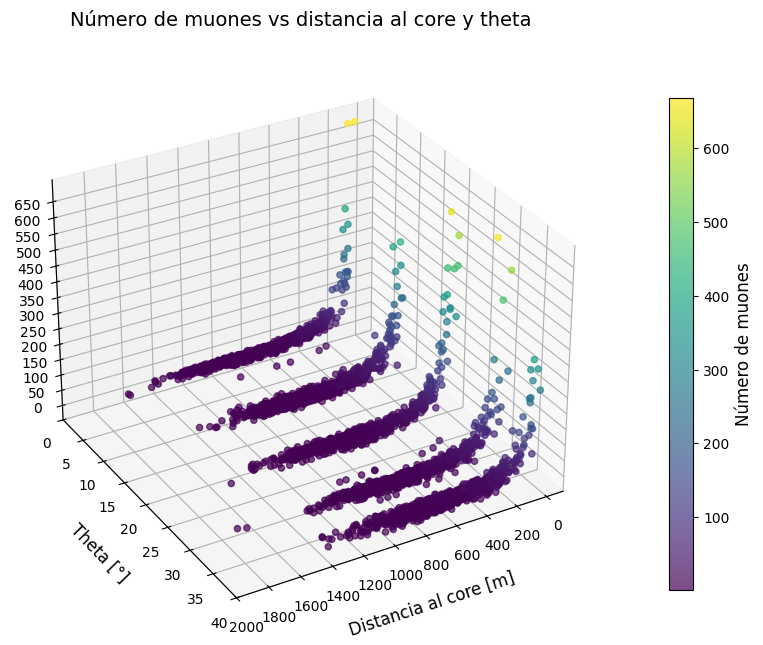

In [7]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Scatter
sc = ax.scatter(
    df_all_theta_r["r_core"],
    df_all_theta_r["theta"],
    df_all_theta_r["nMuones"],
    c=df_all_theta_r["nMuones"], cmap="viridis", alpha=0.7
)

# Labels
ax.set_xlabel("Distancia al core [m]", fontsize=12, labelpad=10)
ax.set_ylabel("Theta [°]", fontsize=12, labelpad=10)
ax.set_zlabel("Número de muones", fontsize=12, labelpad=10)
plt.title("Número de muones vs distancia al core y theta", fontsize=14, pad=20)

# Mejorar ticks
ax.set_xticks(np.arange(0, 2000+1, 200))  # ajustar según rango de r_core
ax.set_yticks(np.arange(0, 40+1, 5))      # ajustar según rango de theta
ax.set_ylim(0,40)
ax.set_zticks(np.arange(0, df_all_theta_r["nMuones"].max()+1, 50))  # ejemplo

# Añadir barra de color
cbar = plt.colorbar(sc, pad=0.1, shrink=0.8)
cbar.set_label("Número de muones", fontsize=12)

# Rotar la vista
ax.view_init(elev=30, azim=60)  # ajustar según conveniencia

# Grid
ax.grid(True)

plt.show()

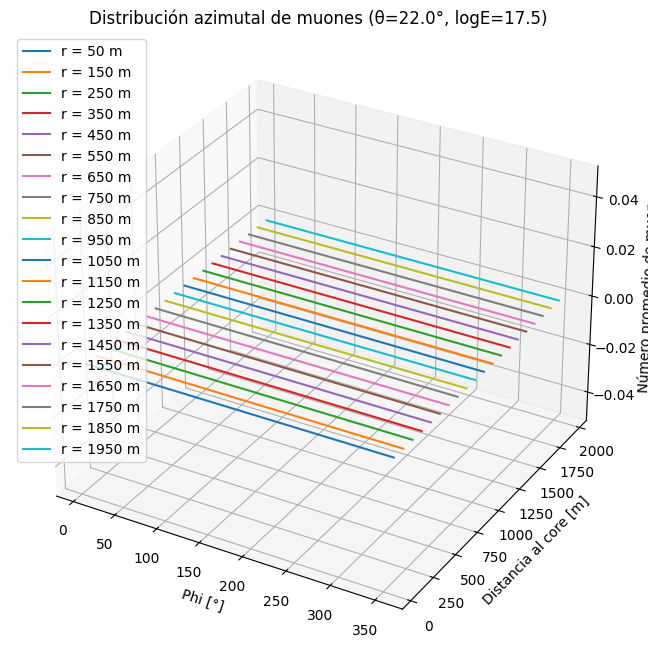

In [9]:
# df_all: DataFrame que contiene todos los eventos leídos
df_umd = pd.DataFrame([{
    "phi": row["phi_REC"],
    "theta": row["theta_REC"],
    "logE_REC": row["logE_REC"],
    "nMuones": c["nMuones"],
    "r_core": c["r_core"]
} for idx, row in df_all.iterrows() for c in row["umdCounters"] if c["nMuones"] > 0])

# Definir bins de r_core
r_bins = np.arange(0, 2000+100, 100)

# Theta y energía fijos (ejemplo)
theta_sel = 22.0
logE_sel = 17.5

# Filtrar DataFrame
df_sel = df_umd[
    (df_umd["theta"] == theta_sel) &
    (np.floor(df_umd["logE_REC"]*10)/10 == logE_sel)  # ejemplo aproximación
].copy()

# Crear lista para promedios por bin de r_core
phi_bins = np.linspace(0, 360, 36)  # bins de 10°
phi_centers = (phi_bins[:-1] + phi_bins[1:])/2
nmu_avg = []

for i in range(len(r_bins)-1):
    r_min, r_max = r_bins[i], r_bins[i+1]
    df_bin = df_sel[(df_sel["r_core"] >= r_min) & (df_sel["r_core"] < r_max)]
    
    # Histograma de nMuones vs phi
    hist, _ = np.histogram(df_bin["phi"], bins=phi_bins, weights=df_bin["nMuones"])
    counts, _ = np.histogram(df_bin["phi"], bins=phi_bins)
    
    # Promedio en cada bin de phi
    with np.errstate(divide='ignore', invalid='ignore'):
        avg = np.nan_to_num(hist / counts)
    nmu_avg.append(avg)

nmu_avg = np.array(nmu_avg)

# ---------------------------
# Plot 3D
# ---------------------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Rango radial = r_bin centers
r_centers = (r_bins[:-1] + r_bins[1:])/2

for i, r in enumerate(r_centers):
    ax.plot(phi_centers, [r]*len(phi_centers), nmu_avg[i], label=f"r = {r:.0f} m")

ax.set_xlabel("Phi [°]")
ax.set_ylabel("Distancia al core [m]")
ax.set_zlabel("Número promedio de muones")
ax.set_title(f"Distribución azimutal de muones (θ={theta_sel:.1f}°, logE={logE_sel:.1f})")
ax.legend()
plt.show()


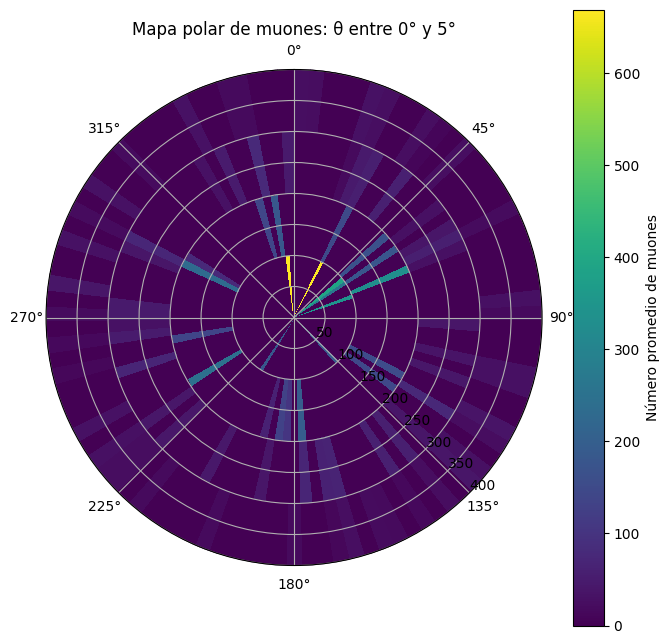

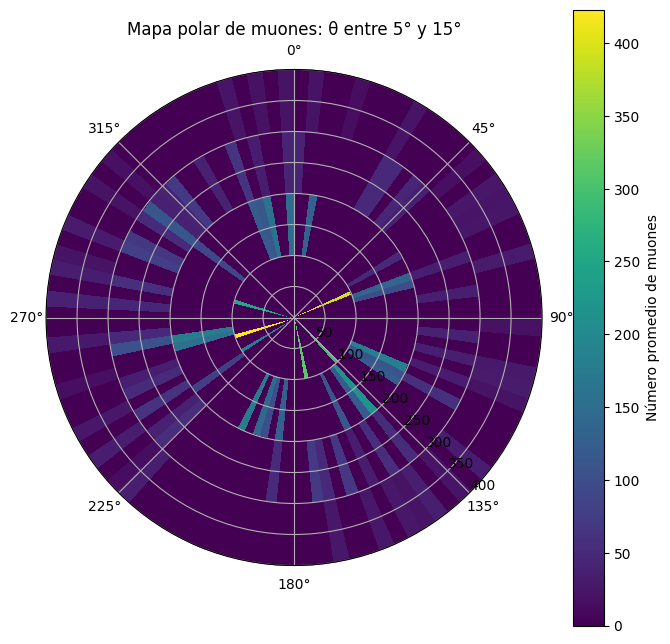

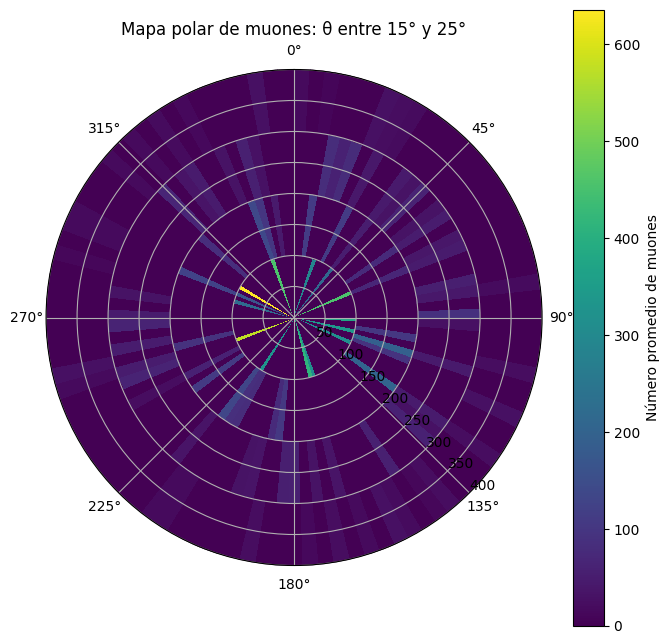

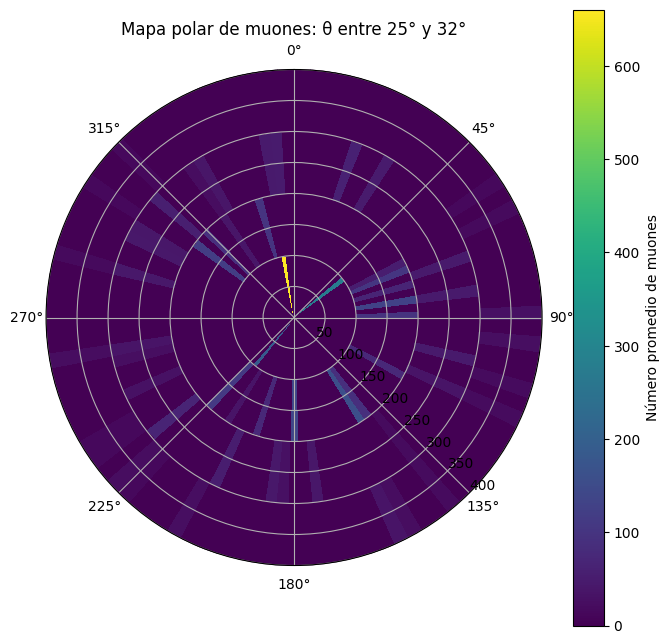

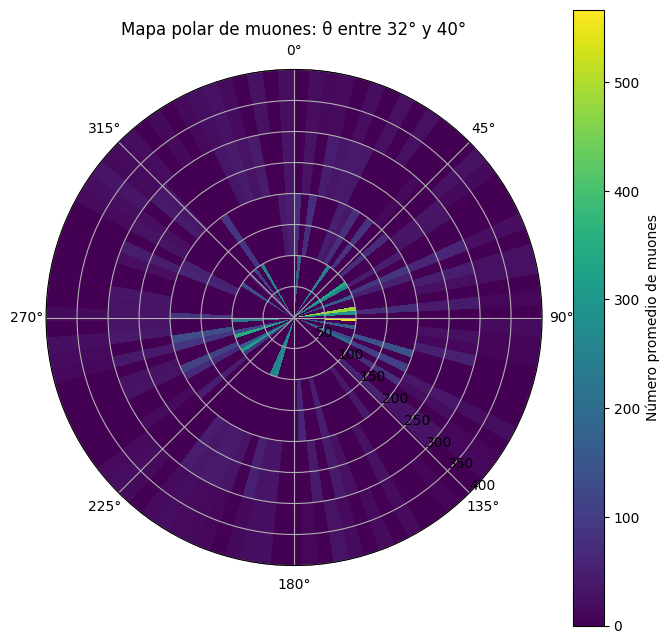

In [10]:
# -----------------------------
# Definir bins
# -----------------------------
r_bins = np.arange(0, 2000+100, 100)      # distancias al core [m]
phi_bins = np.linspace(0, 2*np.pi, 100)   # phi en radianes

# Bins de theta en grados
theta_bins = [(0,5), (5,15), (15,25), (25,32), (32,40)]

# -----------------------------
# Loop por cada bin de theta
# -----------------------------
for th_min, th_max in theta_bins:
    # Filtrar DataFrame por theta
    df_theta = df_umd[(df_umd["theta"] >= th_min) & (df_umd["theta"] < th_max)]
    
    # Inicializar matriz de promedio de muones
    Z = np.zeros((len(phi_bins)-1, len(r_bins)-1))
    
    for i in range(len(r_bins)-1):
        r_min, r_max = r_bins[i], r_bins[i+1]
        df_r = df_theta[(df_theta["r_core"] >= r_min) & (df_theta["r_core"] < r_max)]
        
        for j in range(len(phi_bins)-1):
            phi_min, phi_max = np.rad2deg(phi_bins[j]), np.rad2deg(phi_bins[j+1])
            df_bin = df_r[(df_r["phi"] >= phi_min) & (df_r["phi"] < phi_max)]
            if len(df_bin) > 0:
                Z[j,i] = df_bin["nMuones"].mean()
            else:
                Z[j,i] = 0

    # -----------------------------
    # Plot polar
    # -----------------------------
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    R, Phi = np.meshgrid(r_bins, phi_bins)
    
    c = ax.pcolormesh(Phi, R, Z, cmap="viridis")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(135)
    ax.set_rlim(0, 400)   # ajustar según tus datos
    fig.colorbar(c, ax=ax, label="Número promedio de muones")
    
    plt.title(f"Mapa polar de muones: θ entre {th_min}° y {th_max}°")
    plt.show()
